In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
lines_read = []
with open('events.txt', 'r') as f:
    for line in f:
        line = line.replace('\n', '').split(' ')
        if float(line[0]) > 1:
            break
        lines_read.append(line)
lines_read

[['0.000000000', '33', '39', '1'],
 ['0.000011001', '158', '145', '1'],
 ['0.000050000', '88', '143', '0'],
 ['0.000055000', '174', '154', '0'],
 ['0.000080001', '112', '139', '1'],
 ['0.000123000', '136', '171', '0'],
 ['0.000130001', '173', '90', '0'],
 ['0.000139001', '106', '140', '0'],
 ['0.000148001', '192', '79', '1'],
 ['0.000191001', '118', '149', '0'],
 ['0.000223000', '191', '95', '0'],
 ['0.000223000', '192', '10', '1'],
 ['0.000244000', '181', '130', '1'],
 ['0.000273000', '189', '74', '1'],
 ['0.000283000', '136', '170', '0'],
 ['0.000309000', '20', '39', '1'],
 ['0.000319001', '131', '35', '1'],
 ['0.000401000', '144', '170', '0'],
 ['0.000422001', '18', '110', '0'],
 ['0.000424001', '110', '43', '0'],
 ['0.000448001', '151', '148', '1'],
 ['0.000490001', '98', '124', '1'],
 ['0.000502001', '186', '147', '0'],
 ['0.000514001', '100', '128', '1'],
 ['0.000639000', '19', '117', '0'],
 ['0.000661001', '89', '143', '0'],
 ['0.000688000', '183', '97', '0'],
 ['0.000689000', '

In [16]:
timestamp, x, y, polarity = [], [], [], []

for tt, xx, yy, pp in lines_read:
    timestamp.append(float(tt))
    x.append(int(xx))
    y.append(int(yy))
    polarity.append(int(pp))

In [17]:
pos_x, pos_y, pos_t = [], [], []
neg_x, neg_y, neg_t = [], [], []

for i in range(len(polarity)):
    if polarity[i] == 1:
        pos_x.append(x[i])
        pos_y.append(y[i])
        pos_t.append(timestamp[i])
    else:
        neg_x.append(x[i])
        neg_y.append(y[i])
        neg_t.append(timestamp[i])

In [18]:
print(f'number of events: {len(lines_read)}')
print(f'first timestamp: {timestamp[0]}')
print(f'last timestamp: {timestamp[-1]}')
print(f'maximum x: {max(x)} minimum x: {min(x)}')
print(f'maximum y: {max(y)} minimum y: {min(y)}')

positive_polarity = np.sum(np.where(np.array(polarity) == 1))
negative_polarity = np.sum(np.where(np.array(polarity) == 0))

print(f'positive polarity: {positive_polarity}')
print(f'negative polarity: {negative_polarity}')

number of events: 72046
first timestamp: 0.0
last timestamp: 1.0
maximum x: 239 minimum x: 4
maximum y: 179 minimum y: 1
positive polarity: 1120955291
negative polarity: 1474321744


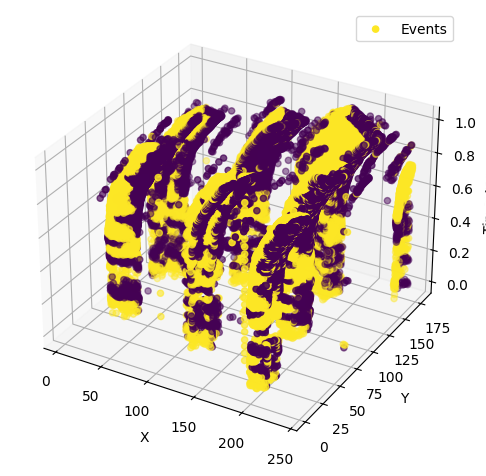

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, timestamp, c=polarity, label='Events')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Timestamp')
ax.legend()

plt.tight_layout()
plt.show()

Plot 3D chart (as in exercise 1.1) but only for the first 8000 events.

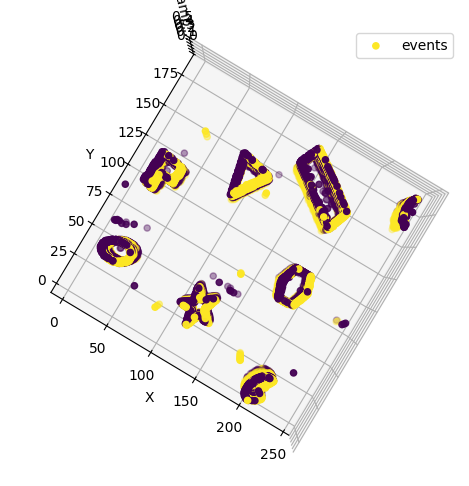

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:8000], y[:8000], timestamp[:8000], c=polarity[:8000], label='events')
ax.view_init(90)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Timestamp')
ax.legend()
plt.tight_layout()
plt.show()

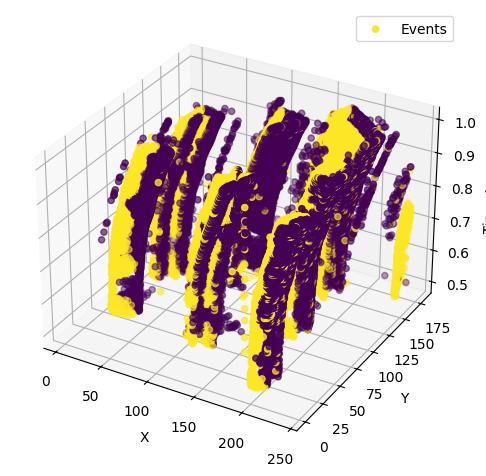

In [21]:
xs_3 = []
ys_3 = []
ts_3 = []
p_3 = []
for t, x, y, p in lines_read:
    if 0.5 <= float(t) <= 1.0:
        xs_3.append(int(x))
        ys_3.append(int(y))
        ts_3.append(float(t))
        p_3.append(int(p))


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xs_3, ys_3, ts_3, c=p_3, label='Events')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Timestamp')
ax.legend()

plt.tight_layout()
plt.show()

13.3

In [22]:
lines_1_2 = []
with open('events.txt', 'r') as f:
    for line in f:
        line = line.replace('\n', '').split(' ')
        if float(line[0]) <= 1:
            continue
        if float(line[0]) >= 2:
            break
        lines_1_2.append(line)

timestamps, xs, ys, polarities = [], [], [], []

for timestamp, x, y, polarity in lines_1_2:
    timestamps.append(float(timestamp))
    xs.append(int(x))
    ys.append(int(y))
    polarities.append(1 if int(polarity) else -1)

In [23]:
print(len(timestamps))

156431


In [24]:
def event_frame(event_coordinates, polarities, shape):
    frame = np.zeros(shape) + 127
    frame = frame.astype(np.uint8)

    for i, (x, y) in enumerate(event_coordinates):
        frame[y, x] = 255 if polarities[i] == 1 else 0

    return frame


In [25]:
tau = 0.01
start_idx = 0
shape = cv2.imread('images/frame_00000000.png').shape

In [26]:
while start_idx < (len(timestamps) - 1):
    temp_timestamps = []
    temp_coords = []
    temp_polarities = []

    start_time = timestamps[start_idx]

    for i in range(start_idx, len(timestamps)):
        if timestamps[i] - start_time >= tau:
            break
        temp_timestamps.append(timestamps[i])
        temp_coords.append((xs[i], ys[i]))
        temp_polarities.append(polarities[i])

    frame = event_frame(temp_coords, temp_polarities, shape)
    cv2.imshow('Frame', frame)
    # plt.imshow(frame)
    # plt.show()
    key = cv2.waitKey(50)

    if key == 27:  # ESC key
        break


    start_idx = i

cv2.destroyAllWindows()